In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

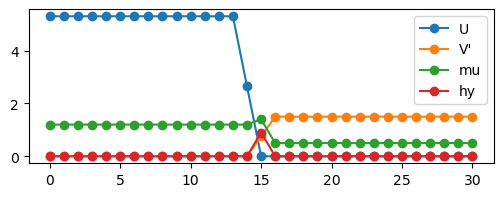

In [2]:
widthS = 15
widthF = 1
widthP = 15

X, Y = widthS+widthF+widthP, 200
lattice = Lattice(X, Y)

t = 1
T = 0.1

muS = 1.2 * t
muP = 0.5 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS + widthF] = muF
mu[widthS + widthF:] = muP

h0 = 0.9 * t
hy = np.zeros_like(mu)
hy[widthS:widthS + widthF] = h0

U0 = 5.3 * t
U = U0 * np.ones(lattice.X)
U[widthS:] = 0
U[widthS-1] = U0/2

V_prime0 = 1.5 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthS] = 0 
V_prime[widthF+widthS-1] = V_prime0/2

V = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hy, '-o', label='hy')

plt.legend()

In [3]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, g_s=V,
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j],
                hy=hy, F0_init=0.1)

d:\miniconda3\envs\master-venv\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\miniconda3\envs\master-venv\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


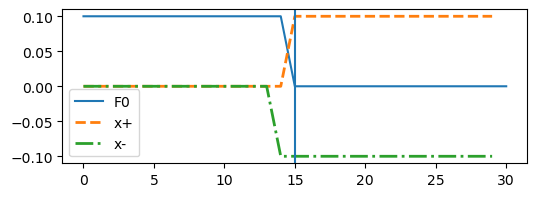

In [4]:
plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(H.F0, label="F0")
if V is not None:
    plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
    # plt.plot(np.imag(H.F_yplus), label="y+", linestyle='-', lw=2)
    # plt.plot(np.imag(H.F_ymin), label="y-", linestyle=':', lw=2)
if V_prime is not None:
    plt.plot(np.real(H.Fuu_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.Fuu_xmin), label="x-", linestyle='-.', lw=2)
    # plt.plot(np.imag(H.Fuu_yplus), label="y+", linestyle='-', lw=2)
    # plt.plot(np.imag(H.Fuu_ymin), label="y-", linestyle=':', lw=2)
plt.legend()
plt.axvline(widthS)

In [ ]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-6, rtol=0.001, maxiter=500, verbose=True, temperature=T, mixing=0.6)

F0:
Absolute error: 0.0001963194274975782
Relative error: 0.0018634603922731087
Average old: (0.43753552866144835+0.04796043819262738j)
Average: (0.4375357412361581+0.04797298139940617j)
F_xplus:
Absolute error: 1.1921017904820325e-05
Relative error: 0.0016243280472290947
Average old: (-0.017979753747825244-0.0029571215283684775j)
Average: (-0.017979950667314122-0.0029571082576284762j)
F_xmin:
Absolute error: 1.1923999526520334e-05
Relative error: 0.0016243100267169788
Average old: (-0.01798044641162087-0.0029574375703132895j)
Average: (-0.017980643396615714-0.002957424157798389j)
F_yplus:
Absolute error: 1.691527052395395e-05
Relative error: 0.0015069259441477631
Average old: (-0.018032214217437104-0.0025957054849466035j)
Average: (-0.018032358405833473-0.0025958287674148635j)
F_ymin:
Absolute error: 1.69152705272002e-05
Relative error: 0.0015069191136110236
Average old: (-0.01803221421743718-0.0025957054849461165j)
Average: (-0.01803235840583343-0.00259582876741575j)
Fuu_xplus:
Absol

In [9]:
F, Fuu, Fdd = H.get_correlations()


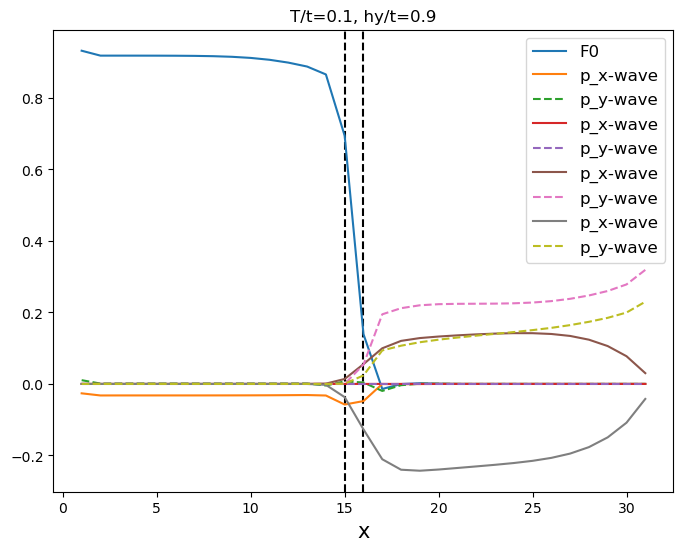

In [10]:
x = np.arange(1, widthS + widthF + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, hy/t={h0}")
axs.axvline(widthS, color='black', linestyle='--')
axs.axvline(widthS+widthF, color='black', linestyle='--')
axs.plot(x, np.real(H.F0), label="F0")
axs.plot(x, np.real(F.swave), label="p_x-wave")
axs.plot(x, np.real(F.dwave), "--", label="p_y-wave")
axs.plot(x, np.real(F.px), label="p_x-wave")
axs.plot(x, np.real(F.py), "--", label="p_y-wave")
axs.plot(x, np.real(Fuu.px), label="p_x-wave")
axs.plot(x, np.real(Fuu.py), "--", label="p_y-wave")
axs.plot(x, np.imag(Fuu.px), label="p_x-wave")
axs.plot(x, np.imag(Fuu.py), "--", label="p_y-wave")
axs.set_xlabel("x", fontsize=15)
# axs.set_xlim(20, 45)
# axs.set_ylim(None, 0.3)
axs.legend(fontsize=12, loc="best")
plt.savefig('../figures/SFP.pdf')
plt.show()